# Imports

In [30]:
import numpy as np 
import pandas as pd 
import yfinance as yf 
import matplotlib.pyplot as plt 


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

### Load Dataset 

In [31]:
data = yf.download("AAPL",start="2015-01-01",end ="2023-01-01")
df = data[['Open','High','Low','Close','Volume']]
df.head(5)

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.671153,24.682228,23.776355,24.214895,212818400
2015-01-05,23.984549,24.064284,23.346674,23.532721,257142000
2015-01-06,23.596948,23.794069,23.173912,23.534933,263188400
2015-01-07,23.743129,23.964614,23.632387,23.864946,160423600
2015-01-08,24.192741,24.839475,24.075353,24.781889,237458000


### Visualizaation 

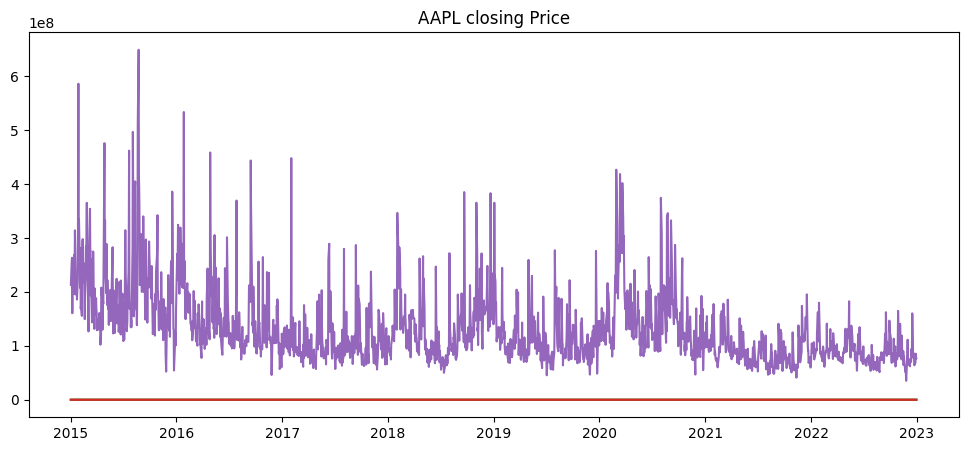

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df)
plt.title("AAPL closing Price")
plt.show()

### Scaling 

In [33]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

### create Sequence

In [34]:
def create_sequence(data,seq_length):
    X,y=[],[]
    for i in range(seq_length,len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X),np.array(y)

SEQ_LENGTH = 60
X,y =create_sequence(scaled_data,SEQ_LENGTH)
print("Shape",X.shape)

Shape (1954, 60, 5)


### Train -Test Split

In [35]:
from sklearn.model_selection import train_test_split

# Assuming X contains features and y contains labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

### BuilD RNN Model

In [36]:
def build_rnn():

    model = Sequential()

    model.add(SimpleRNN(64,input_shape=(SEQ_LENGTH,1)))
    model.add(Dropout(.2))
    model.add(Dense(1))

    model.compile(optimizer="adam",loss= "mse")

    return model 

rnn_model = build_rnn()
rnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

### TRain RNN

In [37]:
early_stop = EarlyStopping(patience = 5,restore_best_weights=True)

rnn_history=rnn_model.fit(X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop])

Epoch 1/30


ValueError: Exception encountered when calling SimpleRNNCell.call().

[1mDimensions must be equal, but are 5 and 1 for '{{node sequential_2_1/simple_rnn_1_1/simple_rnn_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_2_1/simple_rnn_1_1/strided_slice_2, sequential_2_1/simple_rnn_1_1/simple_rnn_cell_1/Cast/ReadVariableOp)' with input shapes: [?,5], [1,64].[0m

Arguments received by SimpleRNNCell.call():
  • sequence=tf.Tensor(shape=(None, 5), dtype=float32)
  • states=('tf.Tensor(shape=(None, 64), dtype=float32)',)
  • training=True

### BUild LSTM

In [ ]:
def build_lstm():

    model = Sequential()
    
    model.add(LSTM(64, input_shape=(SEQ_LENGTH,1)))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    
    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [ ]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    
)

Epoch 1/30


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021 - val_loss: 7.2190e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0019 - val_loss: 6.6638e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0018 - val_loss: 5.7080e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024 - val_loss: 4.2940e-04
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 5.9434e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016 - val_loss: 3.7922e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 3.8630e-04
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013 - val_loss: 4.7190e-04
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 4.6865e-04
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 3.7174e-04
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 3.4308e-04
Epoch 12/30
49/49 ━━━━━━━━━━━━

### Evaluate Model

In [ ]:
# RNN Predictions
rnn_pred = rnn_model.predict(X_test)
rnn_pred = scaler.inverse_transform(rnn_pred)

# LSTM Predictions
lstm_pred = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(y_test)

rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_pred))
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("RNN RMSE:", rnn_rmse)
print("LSTM RMSE:", lstm_rmse)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
RNN RMSE: 2.0790249217816497
LSTM RMSE: 3.2193668304716896


### Visualization comparison

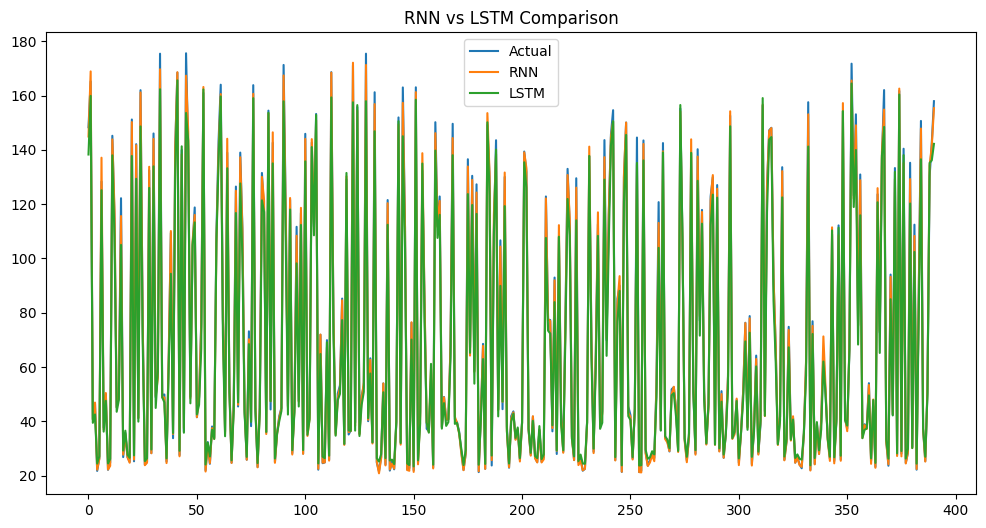

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.legend()
plt.title("RNN vs LSTM Comparison")
plt.show()

### Experiment Table

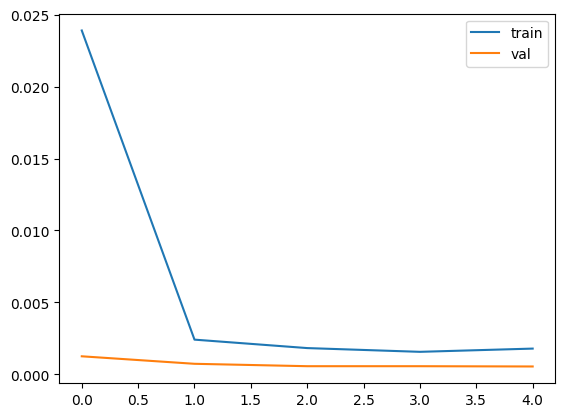

In [ ]:
plt.plot(lstm_history.history['loss'], label='train')
plt.plot(lstm_history.history['val_loss'], label='val')
plt.legend()
plt.show()

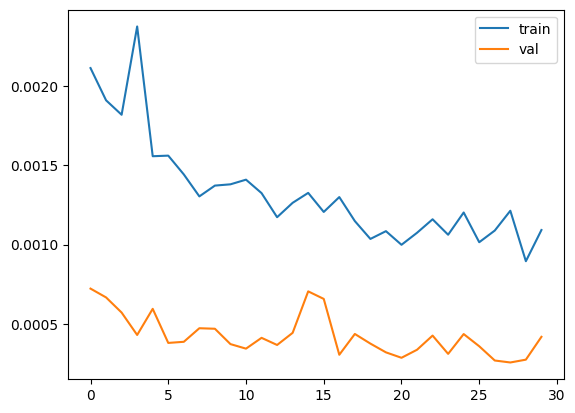

In [ ]:
plt.plot(lstm_history.history['loss'], label='train')
plt.plot(lstm_history.history['val_loss'], label='val')
plt.legend()
plt.show()